# Local Outlier Factor (LOF) for Anomaly Detection

This script uses the unified_dataset.csv and applies Local Outlier Factor (LOF) for fraud anomaly detection. LOF is a density-based anomaly detection algorithm that identifies outliers by comparing the local density of a point to the densities of its neighbors.

The notebook includes:
- Data preprocessing with standard scaling
- **Stability-based hyperparameter tuning** (measures consistency across runs)
- Anomaly score analysis
- Feature importance for anomaly detection
- Visualization of detected anomalies
- **Model export for ensemble integration**

The test data is 40% of the original data.

In [1]:
!pip install --upgrade scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.decomposition import PCA
from itertools import combinations
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

##  Load and Prepare Data

In [3]:
# Load the dataset
df = pd.read_csv("/dsa/groups/casestudycf25/team02/silver/unified_dataset_testing.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (140827, 140)

First few rows:


,npi,rfrg_prvdr_state_abrvtn,year,target,avg_suplr_mdcr_pymt_amt_sum,avg_suplr_mdcr_pymt_amt_min,avg_suplr_mdcr_pymt_amt_max,tot_suplr_nonrntl_hcpcs_cds,tot_suplr_rentl_hcpcs_cds,tot_suplrs_sum,...,total_payment_outlier_by_type,bene_avg_age_outlier,bene_avg_age_zscore_by_type,bene_avg_age_outlier_by_type,bene_avg_risk_scre_outlier,bene_avg_risk_scre_outlier_by_type,drug_suplr_mdcr_stdzd_pymt_amt_outlier,drug_suplr_mdcr_stdzd_pymt_amt_outlier_by_type,elderly_patient_concentration,young_patient_concentration
0,1003000597,OK,2022,0,1.692306,1.692306,1.692306,1.0,0.0,3,...,False,False,-0.549574,False,False,False,False,False,0.0,0.0
1,1003000597,OK,2023,0,23.833223,0.112054,8.331875,5.0,0.0,12,...,False,False,-0.115403,False,False,False,False,False,0.0,0.0
2,1003000902,KY,2021,0,155.711788,0.087436,82.163333,5.0,3.0,32,...,False,False,-0.363841,False,False,False,False,False,0.0,0.0
3,1003000902,KY,2022,0,67.361088,0.028794,38.227500,4.0,1.0,23,...,False,False,-1.214294,False,False,False,False,False,0.0,0.0
4,1003000902,KY,2023,0,40.802223,0.098643,24.145333,3.0,1.0,13,...,False,False,-0.835965,False,False,False,False,False,0.0,0.0


In [4]:
# Check for missing values
print("Missing values per column (top 20):")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing.head(20))

Missing values per column (top 20):
npi                                                            0
specialty                                                      0
n_third_party_entities                                         0
total_invested_usd                                             0
total_value_of_interest                                        0
immediate_family_member                                        0
physician_covered_recipient                                    0
specialty_type                                                 0
specialty_lvl1_Agencies                                        0
nature_sum_other_services                                      0
specialty_lvl1_Allopathic & Osteopathic Physicians             0
specialty_lvl1_Behavioral Health & Social Service Providers    0
specialty_lvl1_Dental Providers                                0
specialty_lvl1_Eye and Vision Services Providers               0
specialty_lvl1_Nursing Service Providers              

In [5]:
# Define columns to exclude from modeling
# These are identifiers, targets, or non-predictive columns
exclude_cols = ['target', 'npi', 'year', 'Rfrg_NPI', 'covered_recipient_npi', 
                'fraud_flag', 'year_leie', 'excltype', ]

# Also exclude date columns
date_cols = [col for col in df.columns if 'date' in col.lower()]
exclude_cols.extend(date_cols)

# Select only numeric columns, excluding identifiers and target
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [col for col in numeric_cols if col not in exclude_cols]

print(f"Number of feature columns: {len(feature_cols)}")
print(f"Excluded columns: {[c for c in exclude_cols if c in df.columns]}")

# Create feature matrix
X = df[feature_cols].copy()

Number of feature columns: 106
Excluded columns: ['target', 'npi', 'year']


##  Train-Test Split and Scaling

In [6]:
# Split data: 60% train, 40% test
X_train, X_test, train_idx, test_idx = train_test_split(
    X, X.index, test_size=0.4, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 84496 samples
Test set size: 56331 samples


In [7]:
# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled using StandardScaler")
print(f"\nTraining data - Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print(f"Test data - Mean: {X_test_scaled.mean():.4f}, Std: {X_test_scaled.std():.4f}")

Features scaled using StandardScaler

Training data - Mean: -0.0000, Std: 0.9905
Test data - Mean: 0.0010, Std: 3.5096


##  Stability-Based Hyperparameter Tuning

Use **stability-based tuning**:
- Run the model multiple times with different data samples
- Measure how consistently the same points are flagged as anomalies
- Higher stability = more reliable model

Use Jaccard similarity to measure consistency across runs.

**Note**: LOF is deterministic, so use bootstrap sampling to introduce variation.

In [8]:
def compute_jaccard_similarity(set1, set2):
    """Compute Jaccard similarity between two sets."""
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0

def compute_lof_stability_score(X, params, n_runs=10, top_k_pct=0.05, sample_ratio=0.8):
    """
    Compute stability score for LOF with given parameters.
    
    Since LOF is deterministic, use bootstrap sampling to introduce variation.
    For each run, train on a random sample and score the full dataset.
    
    Returns:
        stability_score: Average pairwise Jaccard similarity
        separation_score: Mean score separation between anomalies and normal
    """
    n_samples = X.shape[0]
    top_k = int(n_samples * top_k_pct)
    sample_size = int(n_samples * sample_ratio)
    
    flagged_sets = []
    separation_scores = []
    
    for seed in range(n_runs):
        np.random.seed(seed)
        
        # Bootstrap sample for training
        sample_idx = np.random.choice(n_samples, size=sample_size, replace=False)
        X_sample = X[sample_idx]
        
        # Train LOF with novelty=True to score new data
        model = LocalOutlierFactor(
            n_neighbors=params['n_neighbors'],
            contamination=params['contamination'],
            metric=params.get('metric', 'minkowski'),
            leaf_size=params.get('leaf_size', 30),
            novelty=True,
            n_jobs=-1
        )
        model.fit(X_sample)
        
        # Score the full dataset
        # Negate because LOF returns negative scores (more negative = more anomalous)
        scores = -model.score_samples(X)
        
        # Get indices of top k most anomalous points
        top_k_indices = set(np.argsort(scores)[-top_k:])
        flagged_sets.append(top_k_indices)
        
        # Calculate separation score
        threshold = np.percentile(scores, (1 - params['contamination']) * 100)
        anomaly_scores = scores[scores >= threshold]
        normal_scores = scores[scores < threshold]
        if len(anomaly_scores) > 0 and len(normal_scores) > 0:
            separation = (anomaly_scores.mean() - normal_scores.mean()) / scores.std()
            separation_scores.append(separation)
    
    # Compute average pairwise Jaccard similarity
    similarities = []
    for i, j in combinations(range(n_runs), 2):
        sim = compute_jaccard_similarity(flagged_sets[i], flagged_sets[j])
        similarities.append(sim)
    
    stability_score = np.mean(similarities)
    separation_score = np.mean(separation_scores) if separation_scores else 0
    
    return stability_score, separation_score

print("Stability scoring functions defined.")

Stability scoring functions defined.


In [9]:
# Define hyperparameter grid
param_grid = {
    'n_neighbors': [10, 20, 35, 50],
    'contamination': [0.001, 0.002, 0.005],
    'metric': ['minkowski'],
    'leaf_size': [30]
}

# For faster tuning, use a sample of the training data
n_sample = min(20000, X_train_scaled.shape[0])
sample_idx = np.random.choice(X_train_scaled.shape[0], size=n_sample, replace=False)
X_sample = X_train_scaled[sample_idx]

print(f"Running stability-based hyperparameter tuning...")
print(f"Sample size: {n_sample}")
print(f"Parameter combinations: {len(list(ParameterGrid(param_grid)))}")
print(f"Bootstrap runs per combination: 10")

Running stability-based hyperparameter tuning...
Sample size: 20000
Parameter combinations: 12
Bootstrap runs per combination: 10


In [10]:
# Run stability-based grid search
stability_results = []

for params in ParameterGrid(param_grid):
    stability_score, separation_score = compute_lof_stability_score(
        X_sample, params, n_runs=10, top_k_pct=0.05
    )
    
    # Combined score: stability + separation (both are good)
    combined_score = stability_score + 0.5 * separation_score
    
    stability_results.append({
        **params,
        'stability_score': stability_score,
        'separation_score': separation_score,
        'combined_score': combined_score
    })
    
    print(f"n_neighbors={params['n_neighbors']}, contamination={params['contamination']} -> "
          f"Stability: {stability_score:.4f}, Separation: {separation_score:.4f}")

# Convert to DataFrame and sort by combined score
stability_df = pd.DataFrame(stability_results).sort_values('combined_score', ascending=False)


print("Top 5 Parameter Combinations (by combined stability + separation):")
print(stability_df.head())

n_neighbors=10, contamination=0.001 -> Stability: 0.7164, Separation: 20.8183
n_neighbors=20, contamination=0.001 -> Stability: 0.8268, Separation: 22.2977
n_neighbors=35, contamination=0.001 -> Stability: 0.8666, Separation: 22.5713
n_neighbors=50, contamination=0.001 -> Stability: 0.8987, Separation: 22.5790
n_neighbors=10, contamination=0.002 -> Stability: 0.7164, Separation: 12.8245
n_neighbors=20, contamination=0.002 -> Stability: 0.8268, Separation: 14.1239
n_neighbors=35, contamination=0.002 -> Stability: 0.8666, Separation: 14.8175
n_neighbors=50, contamination=0.002 -> Stability: 0.8987, Separation: 15.0213
n_neighbors=10, contamination=0.005 -> Stability: 0.7164, Separation: 6.9526
n_neighbors=20, contamination=0.005 -> Stability: 0.8268, Separation: 7.6658
n_neighbors=35, contamination=0.005 -> Stability: 0.8666, Separation: 8.2354
n_neighbors=50, contamination=0.005 -> Stability: 0.8987, Separation: 8.5511
Top 5 Parameter Combinations (by combined stability + separation):
 

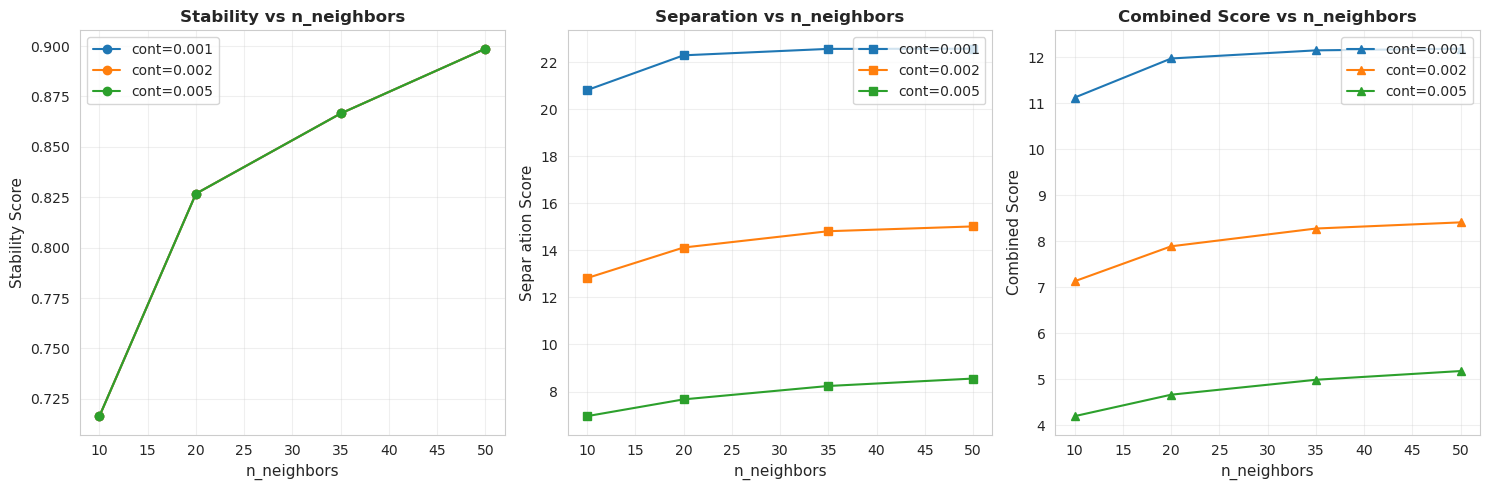

In [11]:
# Visualize stability results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Stability by n_neighbors
for cont in param_grid['contamination']:
    subset = stability_df[stability_df['contamination'] == cont]
    grouped = subset.groupby('n_neighbors')['stability_score'].mean()
    axes[0].plot(grouped.index, grouped.values, marker='o', label=f'cont={cont}')
axes[0].set_xlabel('n_neighbors', fontsize=11)
axes[0].set_ylabel('Stability Score', fontsize=11)
axes[0].set_title('Stability vs n_neighbors', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Separation by n_neighbors
for cont in param_grid['contamination']:
    subset = stability_df[stability_df['contamination'] == cont]
    grouped = subset.groupby('n_neighbors')['separation_score'].mean()
    axes[1].plot(grouped.index, grouped.values, marker='s', label=f'cont={cont}')
axes[1].set_xlabel('n_neighbors', fontsize=11)
axes[1].set_ylabel('Separ ation Score', fontsize=11)
axes[1].set_title('Separation vs n_neighbors', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Combined score by n_neighbors
for cont in param_grid['contamination']:
    subset = stability_df[stability_df['contamination'] == cont]
    grouped = subset.groupby('n_neighbors')['combined_score'].mean()
    axes[2].plot(grouped.index, grouped.values, marker='^', label=f'cont={cont}')
axes[2].set_xlabel('n_neighbors', fontsize=11)
axes[2].set_ylabel('Combined Score', fontsize=11)
axes[2].set_title('Combined Score vs n_neighbors', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('lof_stability_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# Select best parameters
best_row = stability_df.iloc[0]
best_params = {
    'n_neighbors': int(best_row['n_neighbors']),
    'contamination': float(best_row['contamination']),
    'metric': best_row['metric'],
    'leaf_size': int(best_row['leaf_size'])
}

print("Best Parameters (Highest Combined Score):")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nStability Score: {best_row['stability_score']:.4f}")
print(f"Separation Score: {best_row['separation_score']:.4f}")
print(f"Combined Score: {best_row['combined_score']:.4f}")

Best Parameters (Highest Combined Score):
  n_neighbors: 50
  contamination: 0.001
  metric: minkowski
  leaf_size: 30

Stability Score: 0.8987
Separation Score: 22.5790
Combined Score: 12.1882


##  Train Final Model with Best Parameters

In [13]:
# Train final model on full training set
# IMPORTANT: novelty=True is required for scoring new data in the ensemble
print("Training final LOF model with best parameters...")

lof = LocalOutlierFactor(
    n_neighbors=best_params['n_neighbors'],
    contamination=best_params['contamination'],
    metric=best_params['metric'],
    leaf_size=best_params['leaf_size'],
    novelty=True,  # Required for ensemble scoring
    n_jobs=-1
)

lof.fit(X_train_scaled)
print("Model trained successfully!")
print("\nNote: novelty=True is set for ensemble integration.")

Training final LOF model with best parameters...
Model trained successfully!

Note: novelty=True is set for ensemble integration.


In [14]:
# Get predictions and scores
train_predictions = lof.predict(X_train_scaled)  # 1 = normal, -1 = anomaly
test_predictions = lof.predict(X_test_scaled)

# Get anomaly scores
# negate because LOF returns negative scores (more negative = more anomalous)
# After negation: higher = more anomalous (consistent with ensemble)
train_scores = -lof.score_samples(X_train_scaled)
test_scores = -lof.score_samples(X_test_scaled)

# Count anomalies
n_anomalies_train = (train_predictions == -1).sum()
n_anomalies_test = (test_predictions == -1).sum()

print(f"Training set anomalies: {n_anomalies_train} ({n_anomalies_train/len(train_predictions)*100:.2f}%)")
print(f"Test set anomalies: {n_anomalies_test} ({n_anomalies_test/len(test_predictions)*100:.2f}%)")

Training set anomalies: 82 (0.10%)
Test set anomalies: 46 (0.08%)


##  Anomaly Score Distribution Analysis

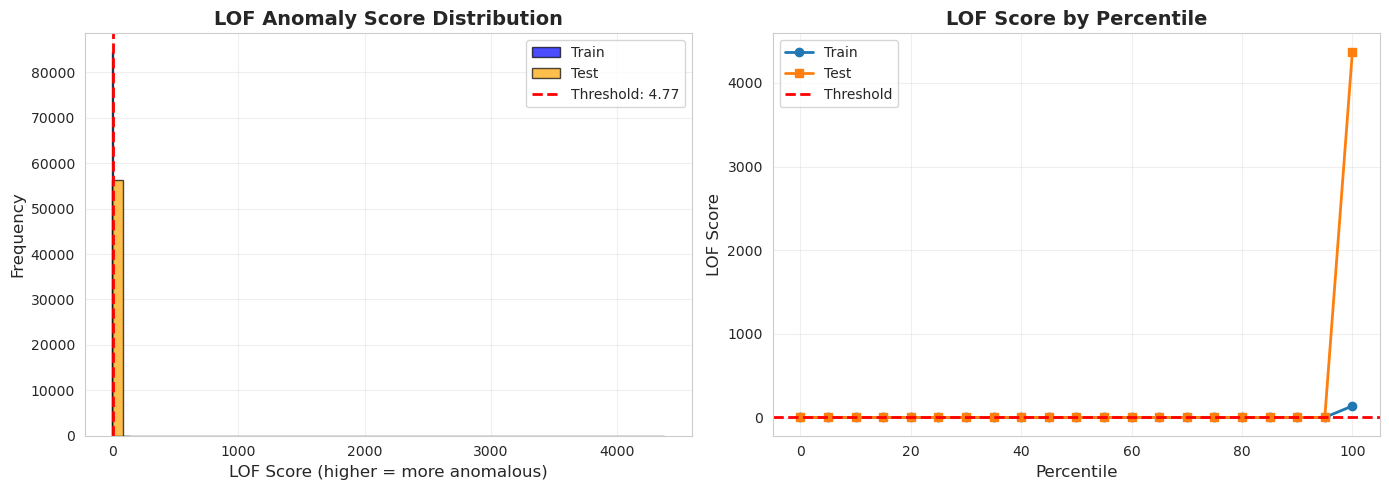

In [15]:
# Visualize anomaly score distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Score distribution histogram
axes[0].hist(train_scores, bins=50, alpha=0.7, label='Train', color='blue', edgecolor='black')
axes[0].hist(test_scores, bins=50, alpha=0.7, label='Test', color='orange', edgecolor='black')
threshold = np.percentile(train_scores, (1 - best_params['contamination']) * 100)
axes[0].axvline(x=threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.2f}')
axes[0].set_xlabel('LOF Score (higher = more anomalous)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('LOF Anomaly Score Distribution', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Score by percentile
percentiles = np.arange(0, 101, 5)
train_percentile_scores = np.percentile(train_scores, percentiles)
test_percentile_scores = np.percentile(test_scores, percentiles)

axes[1].plot(percentiles, train_percentile_scores, marker='o', label='Train', linewidth=2)
axes[1].plot(percentiles, test_percentile_scores, marker='s', label='Test', linewidth=2)
axes[1].axhline(y=threshold, color='red', linestyle='--', linewidth=2, label='Threshold')
axes[1].set_xlabel('Percentile', fontsize=12)
axes[1].set_ylabel('LOF Score', fontsize=12)
axes[1].set_title('LOF Score by Percentile', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig('lof_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# Score statistics
print("LOF Score Statistics:")
print(f"{'Metric':<20} {'Train':>12} {'Test':>12}")
print(f"{'Mean':<20} {train_scores.mean():>12.4f} {test_scores.mean():>12.4f}")
print(f"{'Std':<20} {train_scores.std():>12.4f} {test_scores.std():>12.4f}")
print(f"{'Min':<20} {train_scores.min():>12.4f} {test_scores.min():>12.4f}")
print(f"{'25th Percentile':<20} {np.percentile(train_scores, 25):>12.4f} {np.percentile(test_scores, 25):>12.4f}")
print(f"{'Median':<20} {np.median(train_scores):>12.4f} {np.median(test_scores):>12.4f}")
print(f"{'75th Percentile':<20} {np.percentile(train_scores, 75):>12.4f} {np.percentile(test_scores, 75):>12.4f}")
print(f"{'95th Percentile':<20} {np.percentile(train_scores, 95):>12.4f} {np.percentile(test_scores, 95):>12.4f}")
print(f"{'99th Percentile':<20} {np.percentile(train_scores, 99):>12.4f} {np.percentile(test_scores, 99):>12.4f}")
print(f"{'Max':<20} {train_scores.max():>12.4f} {test_scores.max():>12.4f}")

LOF Score Statistics:
Metric                      Train         Test
Mean                       1.1355       1.2125
Std                        0.6894      18.4230
Min                        0.9482       0.9519
25th Percentile            1.0309       1.0340
Median                     1.0802       1.0844
75th Percentile            1.1559       1.1605
95th Percentile            1.3685       1.3792
99th Percentile            1.9415       1.9870
Max                      137.7922    4373.0739


##  Feature Importance Analysis

In [17]:
# Analyze which features differentiate anomalies from normal samples
anomaly_mask = test_predictions == -1
normal_mask = test_predictions == 1

# Calculate mean values for each group
normal_means = X_test_scaled[normal_mask].mean(axis=0)
anomaly_means = X_test_scaled[anomaly_mask].mean(axis=0)

# Calculate absolute difference
feature_importance = np.abs(anomaly_means - normal_means)

# Create DataFrame for easier analysis
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': feature_importance,
    'normal_mean': normal_means,
    'anomaly_mean': anomaly_means,
    'difference': anomaly_means - normal_means
}).sort_values('importance', ascending=False)

print("Top 20 Features Differentiating Anomalies from Normal Samples:")
print(importance_df.head(20))

Top 20 Features Differentiating Anomalies from Normal Samples:
                                               feature  importance  \
62   form_sum_dividend_profit_or_other_return_on_in...  179.435576   
66                  third_party_recipient_count_entity   17.307796   
89                         physician_covered_recipient   14.300153   
81                       nature_sum_faculty_or_speaker   10.646549   
102                       total_payment_zscore_by_type   10.178111   
71                            nature_count_acquisition    8.322544   
65   form_sum_stock_stock_option_or_any_other_owner...    8.308659   
54                                    non-covered_drug    7.583875   
76                     nature_count_faculty_or_speaker    7.503507   
58                  form_count_cash_or_cash_equivalent    6.644516   
61   form_count_stock_stock_option_or_any_other_own...    6.319323   
73                       nature_count_debt_forgiveness    6.231784   
87                         

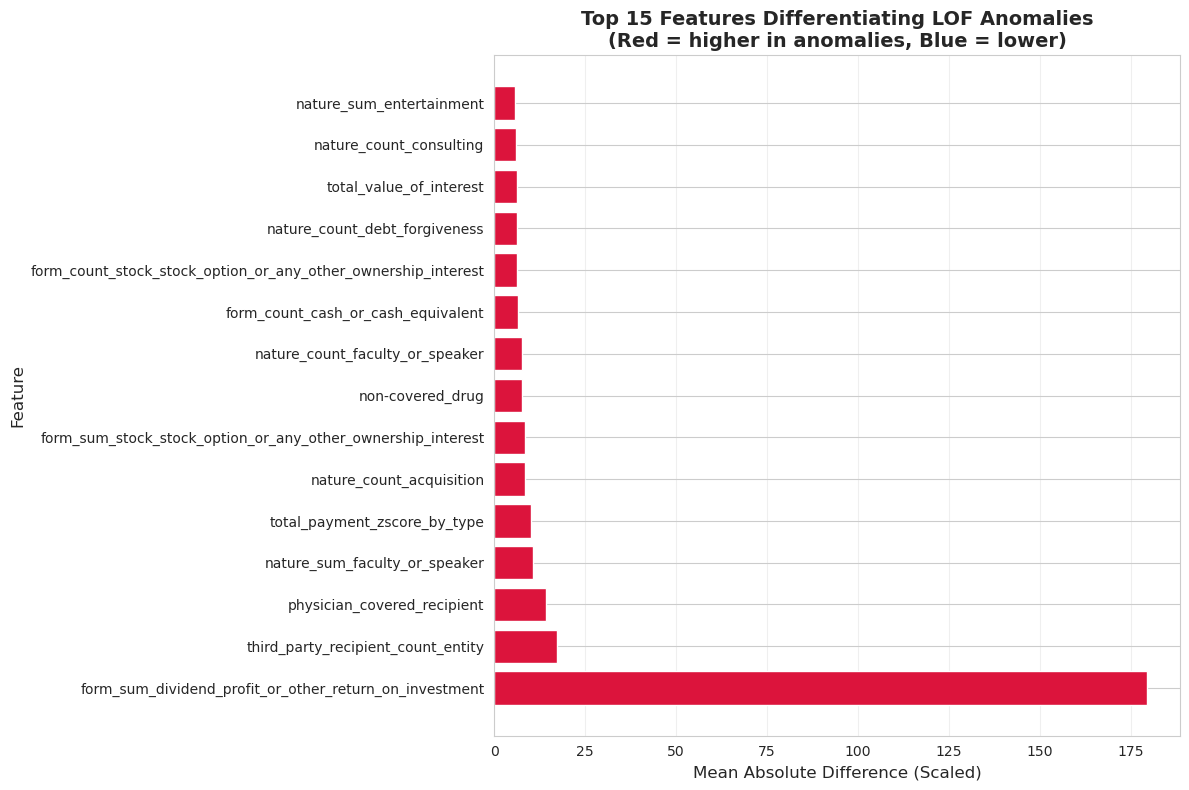

In [18]:
# Visualize top features
top_n = 15
top_features = importance_df.head(top_n)

plt.figure(figsize=(12, 8))
colors = ['crimson' if d > 0 else 'steelblue' for d in top_features['difference'].values]
plt.barh(range(top_n), top_features['importance'].values, color=colors)
plt.yticks(range(top_n), top_features['feature'].values)
plt.xlabel('Mean Absolute Difference (Scaled)', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Features Differentiating LOF Anomalies\n(Red = higher in anomalies, Blue = lower)', 
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
# plt.savefig('lof_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

##  Visualize Anomalies with PCA

In [19]:
# Apply PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_test_pca = pca.fit_transform(X_test_scaled)

print(f"PCA Explained Variance Ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {pca.explained_variance_ratio_.sum():.2%}")

PCA Explained Variance Ratio: [0.92688495 0.01043221]
Total variance explained: 93.73%


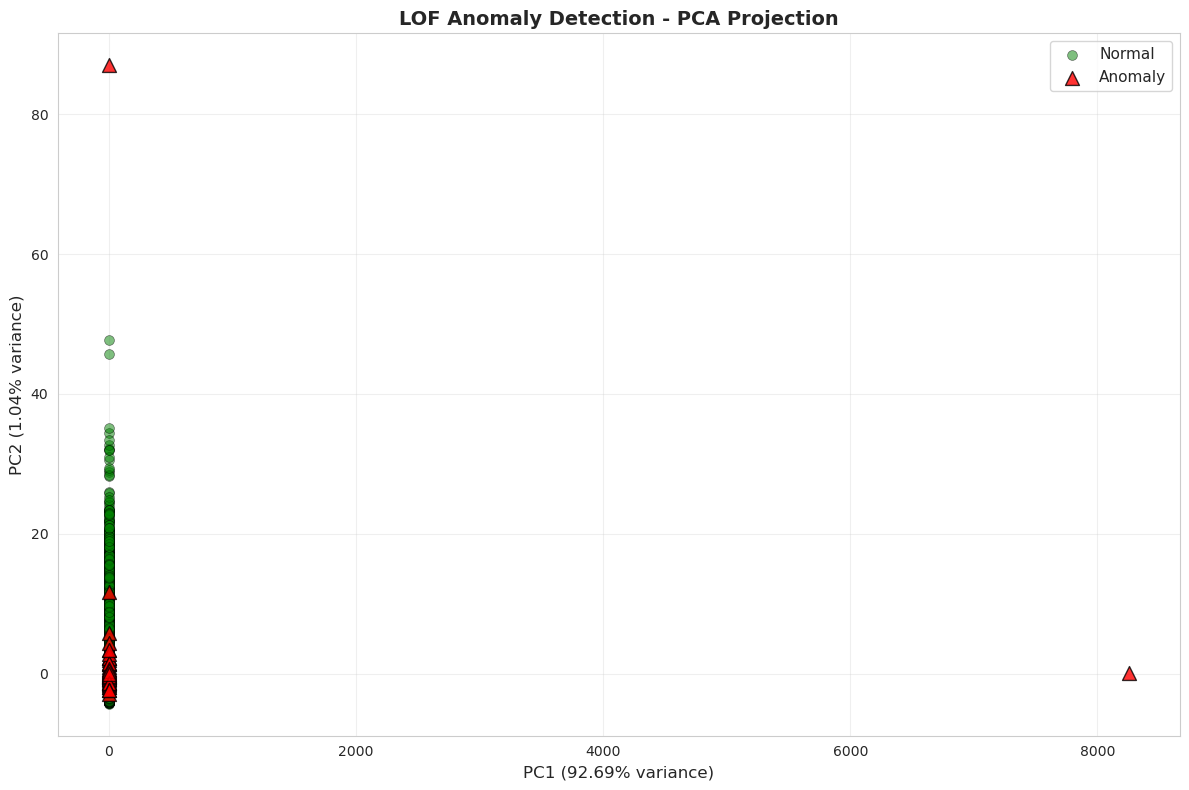

In [20]:
# Create visualization
plt.figure(figsize=(12, 8))

# Plot normal samples
normal_samples = X_test_pca[test_predictions == 1]
plt.scatter(normal_samples[:, 0], normal_samples[:, 1], 
            c='green', s=50, alpha=0.5, label='Normal', edgecolors='k', linewidth=0.5)

# Plot anomalies
anomaly_samples = X_test_pca[test_predictions == -1]
plt.scatter(anomaly_samples[:, 0], anomaly_samples[:, 1], 
            c='red', s=100, alpha=0.8, label='Anomaly', edgecolors='k', linewidth=1, marker='^')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=12)
plt.title('LOF Anomaly Detection - PCA Projection', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('lof_pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

##  K-Distance Plot (LOF Diagnostic)

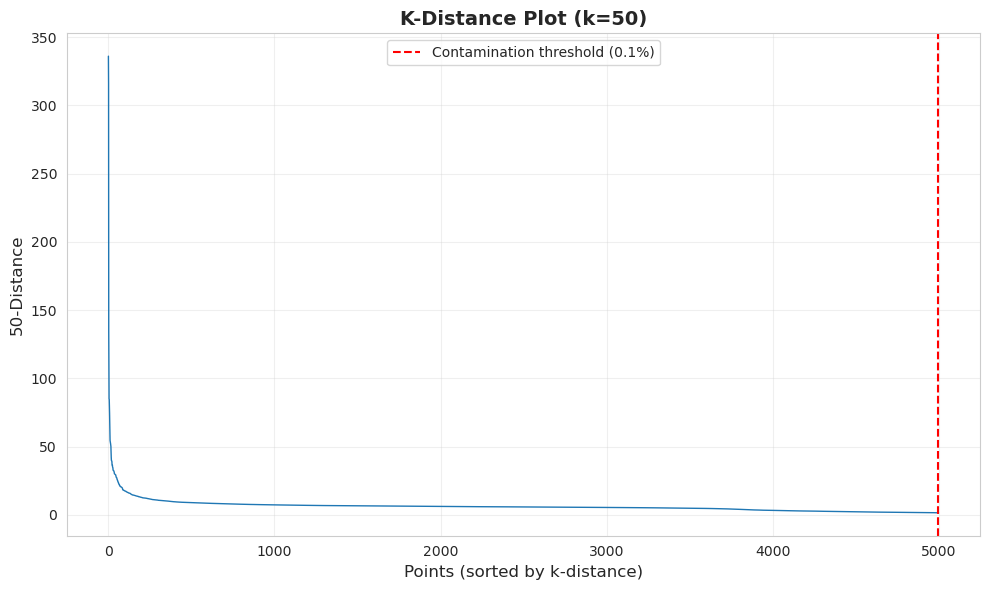

In [21]:
# K-distance plot helps visualize the density around each point
from sklearn.neighbors import NearestNeighbors

# Use a sample for visualization
n_vis_sample = min(5000, len(X_test_scaled))
vis_idx = np.random.choice(len(X_test_scaled), size=n_vis_sample, replace=False)
X_vis = X_test_scaled[vis_idx]

# Compute k-distances
nn = NearestNeighbors(n_neighbors=best_params['n_neighbors'])
nn.fit(X_vis)
distances, _ = nn.kneighbors(X_vis)

# Get the distance to the k-th neighbor
k_distances = distances[:, -1]
k_distances_sorted = np.sort(k_distances)[::-1]

plt.figure(figsize=(10, 6))
plt.plot(range(len(k_distances_sorted)), k_distances_sorted, linewidth=1)
plt.xlabel('Points (sorted by k-distance)', fontsize=12)
plt.ylabel(f'{best_params["n_neighbors"]}-Distance', fontsize=12)
plt.title(f'K-Distance Plot (k={best_params["n_neighbors"]})', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Mark the "elbow" region where outliers typically begin
elbow_idx = int(len(k_distances_sorted) * (1 - best_params['contamination']))
plt.axvline(x=elbow_idx, color='red', linestyle='--', label=f'Contamination threshold ({best_params["contamination"]*100:.1f}%)')
plt.legend()
plt.tight_layout()
# plt.savefig('lof_k_distance_plot.png', dpi=150, bbox_inches='tight')
plt.show()

##  Anomaly Score Heatmap for Top Features

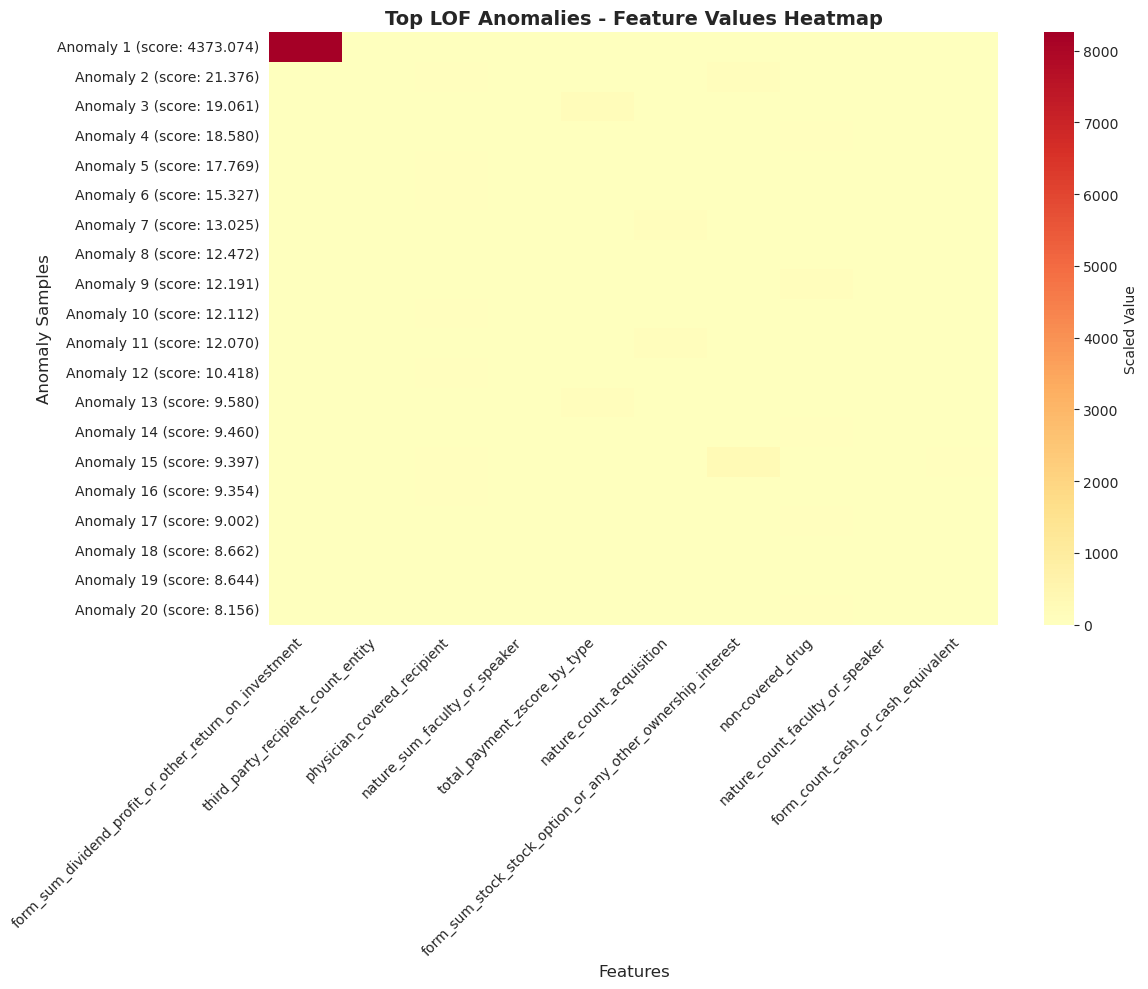

In [22]:
# Select top anomalies by highest score
n_top_anomalies = 20
top_anomaly_indices = np.argsort(test_scores)[-n_top_anomalies:][::-1]

# Get top features
top_feature_names = importance_df.head(10)['feature'].values
top_feature_indices = [feature_cols.index(f) for f in top_feature_names]

# Create heatmap data
heatmap_data = X_test_scaled[top_anomaly_indices][:, top_feature_indices]

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, 
            xticklabels=top_feature_names, 
            yticklabels=[f"Anomaly {i+1} (score: {test_scores[idx]:.3f})" 
                         for i, idx in enumerate(top_anomaly_indices)],
            cmap='RdYlGn_r', 
            center=0,
            cbar_kws={'label': 'Scaled Value'})
plt.title('Top LOF Anomalies - Feature Values Heatmap', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Anomaly Samples', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
# plt.savefig('lof_anomaly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

##  Summary Statistics

In [23]:

print("LOCAL OUTLIER FACTOR (LOF) FRAUD DETECTION SUMMARY")

print(f"\nModel Configuration (Stability-Tuned):")
print(f"  - n_neighbors: {best_params['n_neighbors']}")
print(f"  - contamination: {best_params['contamination']}")
print(f"  - metric: {best_params['metric']}")
print(f"  - leaf_size: {best_params['leaf_size']}")
print(f"  - novelty: True (for ensemble scoring)")
print(f"  - Stability Score: {best_row['stability_score']:.4f}")
print(f"  - Separation Score: {best_row['separation_score']:.4f}")
print(f"  - Features Used: {len(feature_cols)}")

print(f"\nDataset:")
print(f"  - Total Samples: {len(df)}")
print(f"  - Training Samples: {len(X_train)}")
print(f"  - Test Samples: {len(X_test)}")

print(f"\nAnomaly Detection Results (Test Set):")
print(f"  - Normal Samples: {(test_predictions == 1).sum()} ({(test_predictions == 1).sum()/len(test_predictions)*100:.2f}%)")
print(f"  - Anomalous Samples: {(test_predictions == -1).sum()} ({(test_predictions == -1).sum()/len(test_predictions)*100:.2f}%)")

print(f"\nTop 5 Discriminative Features:")
for idx, row in importance_df.head(5).iterrows():
    print(f"  {row['feature']:40s} | Importance: {row['importance']:.4f} | Delta: {row['difference']:+.4f}")

print(f"\nPCA Visualization:")
print(f"  - Variance Explained by PC1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"  - Variance Explained by PC2: {pca.explained_variance_ratio_[1]:.2%}")
print(f"  - Total Variance Explained: {pca.explained_variance_ratio_.sum():.2%}")

LOCAL OUTLIER FACTOR (LOF) FRAUD DETECTION SUMMARY

Model Configuration (Stability-Tuned):
  - n_neighbors: 50
  - contamination: 0.001
  - metric: minkowski
  - leaf_size: 30
  - novelty: True (for ensemble scoring)
  - Stability Score: 0.8987
  - Separation Score: 22.5790
  - Features Used: 106

Dataset:
  - Total Samples: 140827
  - Training Samples: 84496
  - Test Samples: 56331

Anomaly Detection Results (Test Set):
  - Normal Samples: 56285 (99.92%)
  - Anomalous Samples: 46 (0.08%)

Top 5 Discriminative Features:
  form_sum_dividend_profit_or_other_return_on_investment | Importance: 179.4356 | Delta: +179.4356
  third_party_recipient_count_entity       | Importance: 17.3078 | Delta: +17.3078
  physician_covered_recipient              | Importance: 14.3002 | Delta: +14.3002
  nature_sum_faculty_or_speaker            | Importance: 10.6465 | Delta: +10.6465
  total_payment_zscore_by_type             | Importance: 10.1781 | Delta: +10.1781

PCA Visualization:
  - Variance Explained 

##  Save Models Ensemble Integration

In [24]:
# Save the trained model
joblib.dump(lof, 'lof_model.pkl')
print("Model saved to 'lof_model.pkl'")

# Save the scaler
joblib.dump(scaler, 'lof_scaler.pkl')
print("Scaler saved to 'lof_scaler.pkl'")

# Save reference scores for z-score normalization in ensemble
reference_data = {
    'train_scores': train_scores,
    'train_mean': float(train_scores.mean()),
    'train_std': float(train_scores.std()),
    'threshold': float(np.percentile(train_scores, 95)),
    'feature_cols': feature_cols,
    'feature_importance': importance_df.set_index('feature')['importance'].to_dict(),
    'best_params': best_params,
    'stability_score': float(best_row['stability_score']),
    'separation_score': float(best_row['separation_score'])
}
joblib.dump(reference_data, 'lof_reference_scores.pkl')
print("Reference scores saved to 'lof_reference_scores.pkl'")

print(f"\nReference Statistics:")
print(f"  - Training Score Mean: {reference_data['train_mean']:.4f}")
print(f"  - Training Score Std: {reference_data['train_std']:.4f}")
print(f"  - 95th Percentile Threshold: {reference_data['threshold']:.4f}")

Model saved to 'lof_model.pkl'
Scaler saved to 'lof_scaler.pkl'
Reference scores saved to 'lof_reference_scores.pkl'

Reference Statistics:
  - Training Score Mean: 1.1355
  - Training Score Std: 0.6894
  - 95th Percentile Threshold: 1.3685


In [25]:
# Create output DataFrame with predictions and scores
output_df = X_test.copy()
output_df['lof_score'] = test_scores
output_df['is_anomaly'] = (test_predictions == -1).astype(int)
output_df['prediction'] = test_predictions

# Sort by anomaly score (most anomalous first)
output_df = output_df.sort_values('lof_score', ascending=False)

print("Top 10 Most Anomalous Samples:")
print(output_df[['lof_score', 'is_anomaly', 'prediction']].head(10))

# Export to CSV
output_df.to_csv('lof_predictions.csv', index=True)
print("\nPredictions exported to 'lof_predictions.csv'")

Top 10 Most Anomalous Samples:
          lof_score  is_anomaly  prediction
100010  4373.073943           1          -1
118987    21.376402           1          -1
130370    19.061489           1          -1
7136      18.580452           1          -1
48467     17.768604           1          -1
91968     15.327364           1          -1
93340     13.024845           1          -1
21860     12.471609           1          -1
92121     12.191017           1          -1
59869     12.111764           1          -1

Predictions exported to 'lof_predictions.csv'
